In [1]:
import json
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [2]:
with open('/content/train_spider.json') as file:
  spider_data = json.load(file)

In [5]:
# we need only raw sql queries.
queries = [item['query'] for item in spider_data]
print(f"total sql queries loaded: {len(queries)}")
print(f"example query: {queries[0]}")

total sql queries loaded: 7000
example query: SELECT count(*) FROM head WHERE age  >  56


In [7]:
# tokenization
# normally, keras tokenizer uses a built-in filter string that contains
# every single punctuation mark.
# it automatically deletes every character it finds in that string
# before learning the vocabulary.
# so if we pass a sql query, then it will remove all the *, =, > etc symbols..
# soo we need custom filter!

custom_filters = '"#$%&+-./:;<>?@[\\]^_`{|}~\t\n'
tokenizer = Tokenizer(filters=custom_filters, lower = True)
tokenizer.fit_on_texts(queries)
total_words = len(tokenizer.word_index)+1
print(f"Total unique tokens(vocabulary size): {total_words}")

Total unique tokens(vocabulary size): 3004


In [8]:
# n gram sequence.
# it is basically a growing list that teaches the model how to predict the future step by step.
# we need to break every query into smaller chunks to show cause and effect.

input_sequences = []
for line in queries:
  token_list = tokenizer.texts_to_sequences([line])[0]
  for i in range(1, len(token_list)):
    n_gram_sequence = token_list[:i+1]
    input_sequences.append(n_gram_sequence)

print(f"Total N-gram sequences: {len(input_sequences)}")
print(f"example N-gram sequence: {input_sequences[0]}")


Total N-gram sequences: 136105
example N-gram sequence: [4, 15]


In [9]:
print(f"example N-gram sequence: {input_sequences[1]}")

example N-gram sequence: [4, 15, 3]


In [10]:
# pad sequences to uniform length
max_seq_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen = max_seq_len, padding = 'pre'))

In [11]:
# X(input features), y(target next word)
X, labels = input_sequences[:, :-1], input_sequences[:, -1]
y = to_categorical(labels, num_classes = total_words)

In [12]:
print("--- Shapes Ready for Model Training ---")
print(f"Max Sequence Length: {max_seq_len}")
print(f"Input Features Shape (X): {X.shape}")
print(f"Target Labels Shape (y): {y.shape}")

--- Shapes Ready for Model Training ---
Max Sequence Length: 127
Input Features Shape (X): (136105, 126)
Target Labels Shape (y): (136105, 3004)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
model = Sequential()
model.add(Embedding(input_dim=total_words, output_dim=100, input_length=max_seq_len-1))
model.add(LSTM(150))
model.add(Dense(total_words, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='loss', patience=5, verbose=1)

In [15]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X, y, epochs=100, callbacks=[early_stop], verbose=1)

Epoch 1/100
4254/4254 ━━━━━━━━━━━━━━━━━━━━ 50s 11ms/step - accuracy: 0.4325 - loss: 3.1384
Epoch 2/100
4254/4254 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.5472 - loss: 2.2056
Epoch 3/100
4254/4254 ━━━━━━━━━━━━━━━━━━━━ 81s 10ms/step - accuracy: 0.6082 - loss: 1.7712
Epoch 4/100
4254/4254 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.6609 - loss: 1.4555
Epoch 5/100
4254/4254 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.7008 - loss: 1.2442
Epoch 6/100
4254/4254 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - accuracy: 0.7299 - loss: 1.0953
Epoch 7/100
4254/4254 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.7527 - loss: 0.9885
Epoch 8/100
4254/4254 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - accuracy: 0.7709 - loss: 0.9081
Epoch 9/100
4254/4254 ━━━━━━━━━━━━━━━━━━━━ 81s 10ms/step - accuracy: 0.7841 - loss: 0.8464
Epoch 10/100
4254/4254 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - accuracy: 0.7963 - loss: 0.7970
Epoch 11/100
4254/4254 ━━━━━━━━━━━━━━━━━━━━ 81s 10ms/step - accuracy: 0.8054 - loss: 0.75

       FINAL TRAINING METRICS        
Final Loss (Categorical CE): 0.4873
Final Accuracy:              87.31%
Perplexity:                  1.63


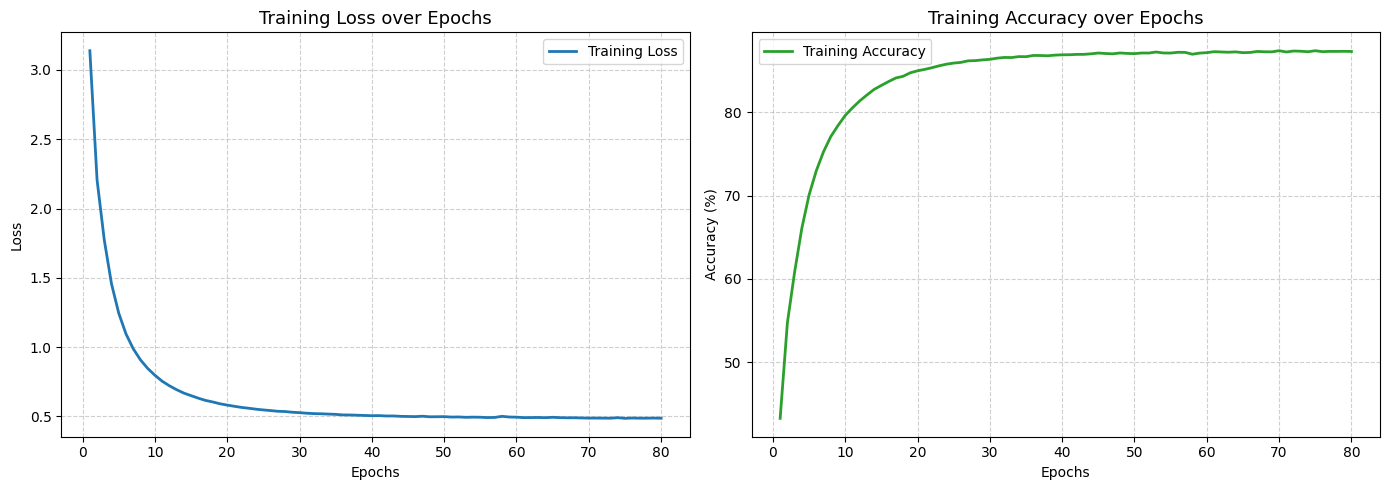

In [16]:
import matplotlib.pyplot as plt
import numpy as np

final_loss = history.history['loss'][-1]
final_acc = history.history['accuracy'][-1]
perplexity = np.exp(final_loss)

print("       FINAL TRAINING METRICS        ")
print("=" * 40)
print(f"Final Loss (Categorical CE): {final_loss:.4f}")
print(f"Final Accuracy:              {final_acc * 100:.2f}%")
print(f"Perplexity:                  {perplexity:.2f}")  # ow surprised or confused a model is when predicting the next word in a sequence.

epochs_range = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.title('Training Loss over Epochs', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc * 100 for acc in history.history['accuracy']], label='Training Accuracy', color='#2ca02c', linewidth=2)
plt.title('Training Accuracy over Epochs', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
import pickle
from google.colab import files

model.save('sql_lstm_model.h5')

with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('max_len.pkl', 'wb') as handle:
    pickle.dump(max_seq_len, handle, protocol=pickle.HIGHEST_PROTOCOL)